<a href="https://colab.research.google.com/github/LeonimerMelo/CNNs/blob/Convolutional-Neural-Networks/CNN_MNIST_digits_optimizers_comparison_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from tensorflow import keras
import keras # Import the Keras library
from keras.datasets import mnist # Load the MNIST dataset
from keras.models import Sequential # Initialize a sequential model
from keras.layers import Dense, Dropout, Flatten, Input
from keras.layers import Conv2D, MaxPooling2D
import numpy as np

In [ ]:
# Load the MNIST dataset from Keras
(x_train, y_train), (x_test, y_test) = mnist.load_data()
# Print the shape of the training and test data
print(x_train.shape, y_train.shape)
# Reshape the training and test data to 4 dimensions
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)
print(x_train.shape)

(60000, 28, 28) (60000,)
(60000, 28, 28, 1)


In [ ]:
# Convert the labels to categorical format
y_train = keras.utils.to_categorical(y_train)
y_test = keras.utils.to_categorical(y_test)
print(x_train.max(), x_train.min())
# Convert the pixel values to floats between 0 and 1
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
print(x_train.max(), x_train.min())

255 0
1.0 0.0


In [ ]:
"""
  Builds a CNN model for MNIST digit classification.

  Args:
    optimizer: The optimizer to use for training the model.

  Returns:
    A compiled Keras model.
  """

def build_model(optimizer):
    model = Sequential()
    model.add(Input((28,28,1))) # Define the input shape
    model.add(Conv2D(32, kernel_size=(3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))

    model.add(layers.Conv2D(64, (5, 5), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(Dropout(0.25))

    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(num_classes, activation='softmax'))
    model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    return model

In [ ]:
# Define the batch size
batch_size = 60
# Define the number of epochs to train the model for
epochs = 10
optimizers=['Adagrad','Adam','SGD', 'RMSprop']
histories ={opt:build_model(opt).fit(x_train,y_train,batch_size=batch_size,
  epochs=epochs,verbose=1,validation_data=(x_test,y_test)) for opt in optimizers}

Epoch 1/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.4143 - loss: 1.8841 - val_accuracy: 0.8403 - val_loss: 0.7328
Epoch 2/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7539 - loss: 0.8449 - val_accuracy: 0.8829 - val_loss: 0.4855
Epoch 3/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8092 - loss: 0.6437 - val_accuracy: 0.8953 - val_loss: 0.4021
Epoch 4/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8326 - loss: 0.5604 - val_accuracy: 0.9061 - val_loss: 0.3576
Epoch 5/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8477 - loss: 0.5094 - val_accuracy: 0.9121 - val_loss: 0.3301
Epoch 6/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8582 - loss: 0.4790 - val_accuracy: 0.9163 - val_loss: 0.3098
Epoch 7/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8656 - loss: 0.4549 - val_accuracy: 0.9198 - val_loss: 0.2931
Epoch 8/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8693 - loss: 0.4395 - 

In [ ]:
import matplotlib.pyplot as plt
# Função para plotar os gráficos da acurácia (accuracy) e da perda (loss)
def plot_acc_loss(h,model):
  plt.figure(figsize = (11,5))
  plt.subplot(1,2,1)
  plt.plot(h.history['loss'], label = 'Treino')
  plt.plot(h.history['val_loss'], label = 'Validação')
  plt.xlabel('Épocas')
  plt.ylabel('Função Custo')
  plt.title('loss')
  plt.xticks()
  plt.yticks()
  plt.legend()
  plt.grid()
  plt.subplot(1,2,2)
  plt.plot(h.history['accuracy'], label = 'Treino')
  plt.plot(h.history['val_accuracy'], label = 'Validação')
  plt.xlabel('Épocas')
  plt.ylabel('Acurácia')
  plt.title('accuracy')
  plt.xticks()
  plt.yticks()
  plt.legend()
  plt.tight_layout()
  plt.grid()
  plt.suptitle('model: '+str(model))
  plt.subplots_adjust(top=0.88)
  plt.show()


 Adagrad


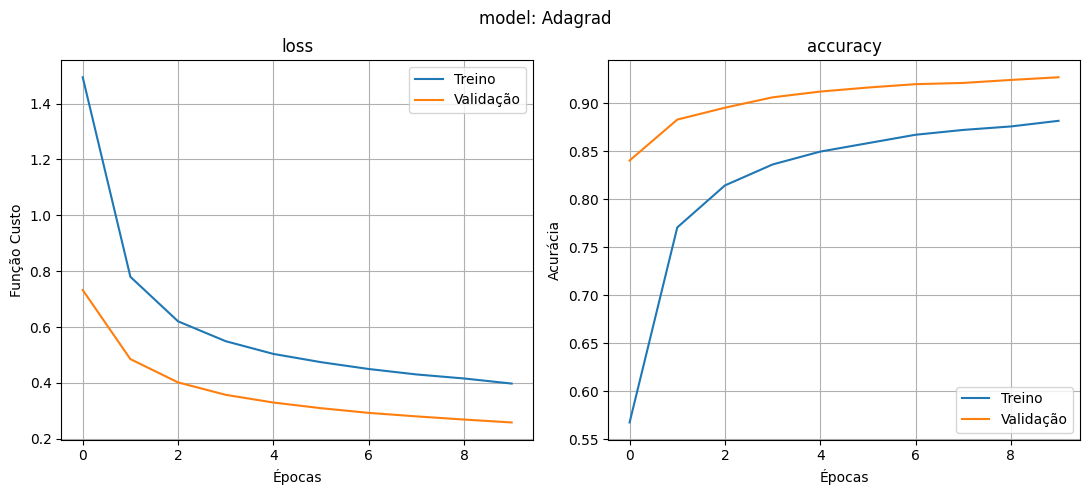


 Adam


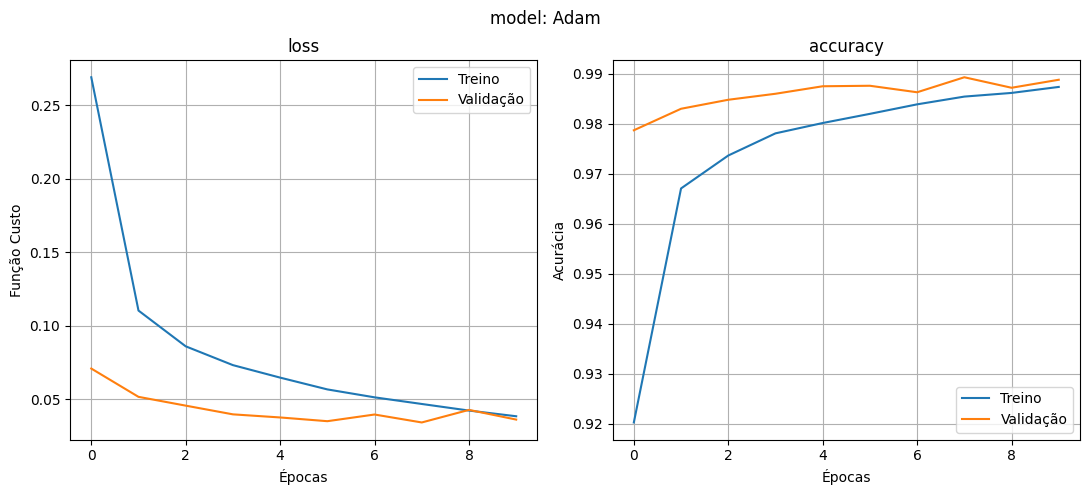


 SGD


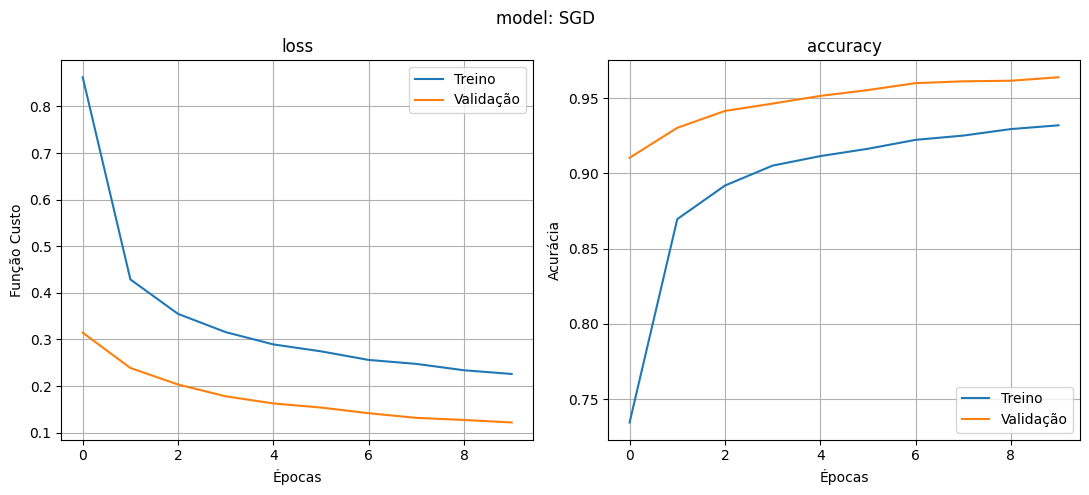


 RMSprop


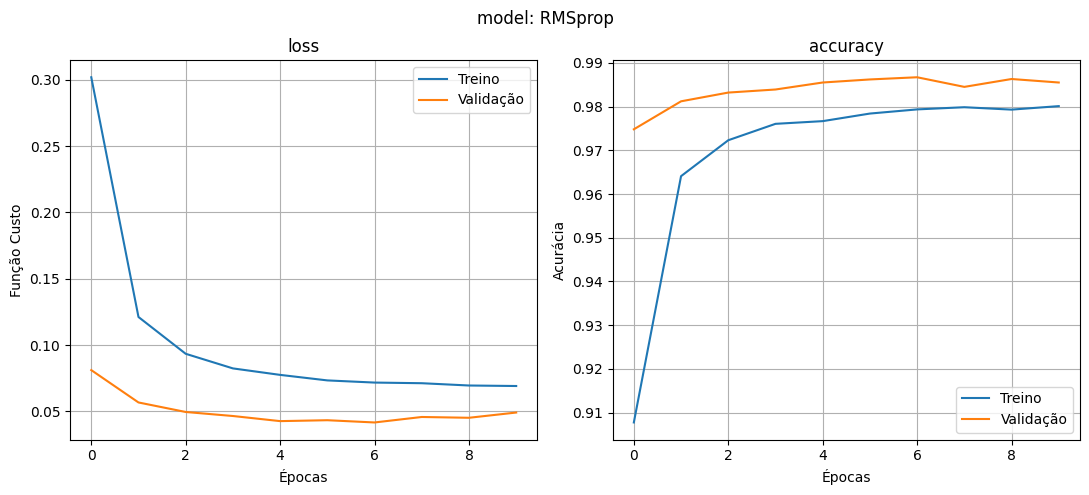

In [ ]:
for key, value in histories.items():
  print('\n',key)
  plot_acc_loss(histories[key], key)